In [1]:
!pip install /kaggle/input/quant-metrics-001/other/default/2/quant_metrics-1.0.0-py3-none-any.whl

Processing /kaggle/input/quant-metrics-001/other/default/2/quant_metrics-1.0.0-py3-none-any.whl


STRATEGY PERFORMANCE SUMMARY
Total Return:              0.00%
CAGR:                      0.00%
Sharpe Ratio:             0.000
Sortino Ratio:            0.000
Max Drawdown:              0.00%
Calmar Ratio:             0.000
Volatility:                0.00%


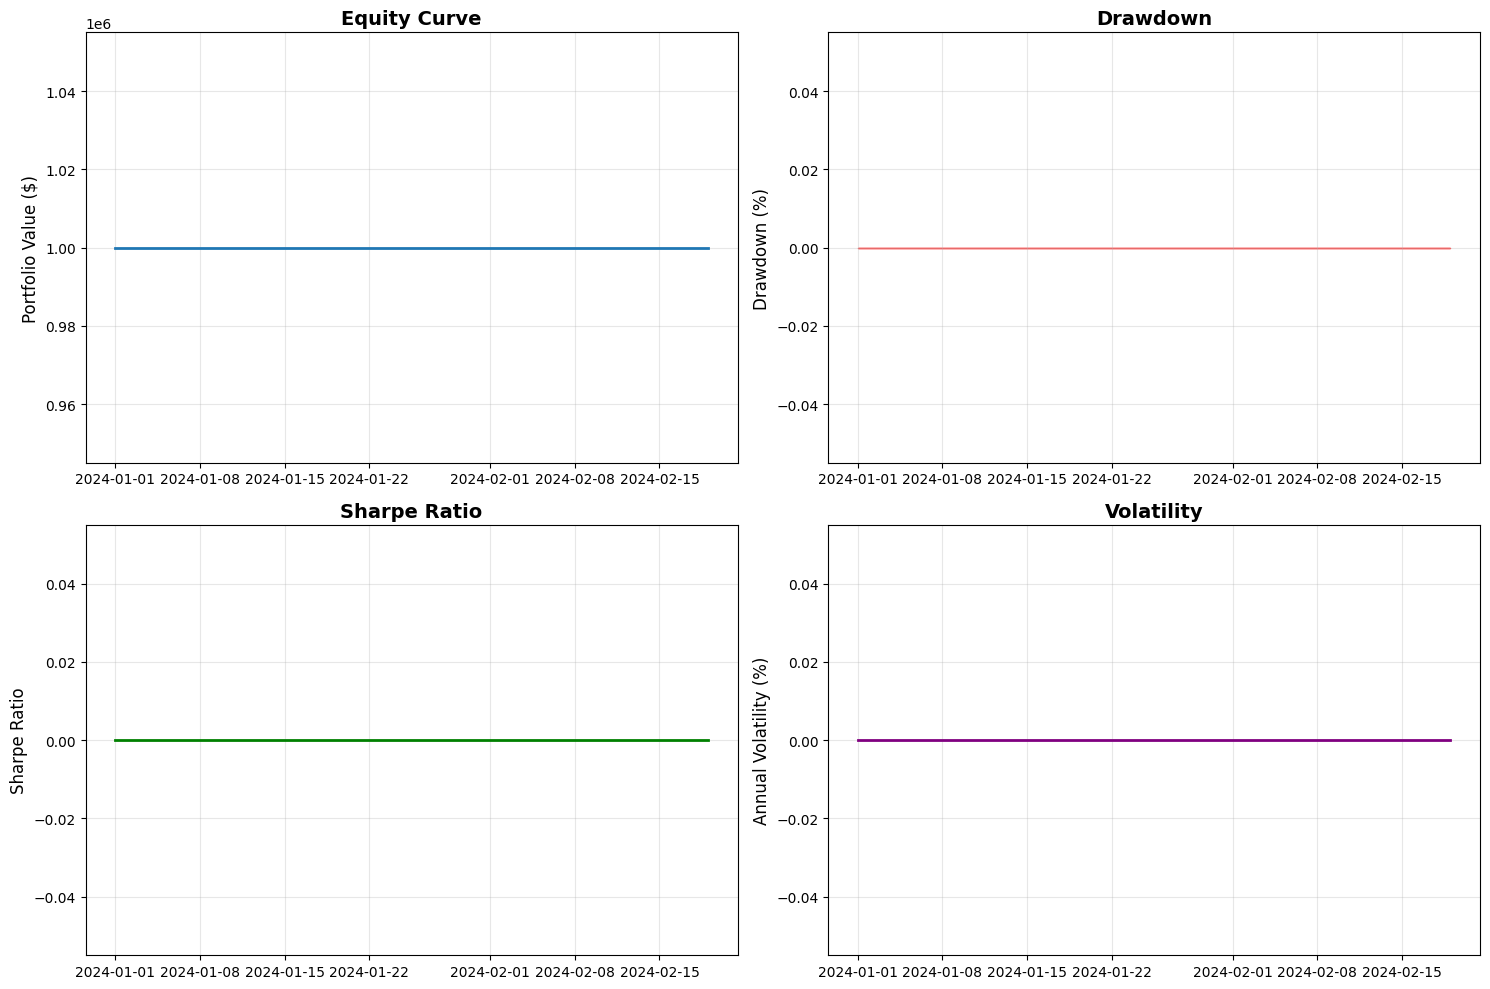

In [2]:
# Installation
#!pip install quant_metrics-1.0.0-py3-none-any.whl

# Basic usage
from Quant_metrics import PortfolioMetrics, StrategyAnalyzer
import pandas as pd
import numpy as np

# Input: Price and weight DataFrames
dates = pd.date_range('2024-01-01', periods=50, freq='D')
prices = pd.DataFrame({'TEST': np.ones(50)}, index=dates)
weights = pd.DataFrame({'TEST': np.ones(50)}, index=dates)

# Analyze strategy
metrics = PortfolioMetrics(prices, weights, initial_capital=1000000)
analyzer = StrategyAnalyzer(metrics)

# Generate performance report
report = analyzer.generate_report()
analyzer.print_summary()
analyzer.plot_performance()


In [3]:
Nq_data = pd.read_csv("/kaggle/input/nasdaq-cme-future-nq/NQ_in_daily.csv")
Nq_data

,datetime,symbol,open,high,low,close,volume
0,1999-06-29 22:00:00,CME_MINI:NQ1!,2293.50,2348.50,2268.50,2325.50,2456.0
1,1999-06-30 22:00:00,CME_MINI:NQ1!,2326.00,2357.00,2295.00,2347.50,1247.0
2,1999-07-05 22:00:00,CME_MINI:NQ1!,2383.50,2410.00,2376.50,2396.00,1247.0
3,1999-07-06 22:00:00,CME_MINI:NQ1!,2365.00,2367.50,2341.00,2352.00,3440.0
4,1999-07-07 22:00:00,CME_MINI:NQ1!,2368.00,2405.00,2350.50,2388.00,3604.0
...,...,...,...,...,...,...,...
6643,2025-10-05 22:00:00,CME_MINI:NQ1!,25000.00,25252.75,24995.00,25184.75,410714.0
6644,2025-10-06 22:00:00,CME_MINI:NQ1!,25184.50,25275.00,24984.75,25039.25,532252.0
6645,2025-10-07 22:00:00,CME_MINI:NQ1!,25059.75,25364.75,25026.25,25331.00,436421.0
6646,2025-10-08 22:00:00,CME_MINI:NQ1!,25351.50,25394.00,25160.75,25289.25,493934.0


In [4]:
Nq_data = Nq_data.loc[Nq_data["datetime"]>="2015-01-01 22:00:00"]

In [5]:
# If Nq_data["datetime"] is a Series of strings/datetimes
Nq_data["datetime"] = pd.to_datetime(Nq_data["datetime"]).dt.strftime('%Y/%m/%d')

print("Converted dates:")
print(Nq_data["datetime"].head())


Converted dates:
3935    2015/01/04
3936    2015/01/05
3937    2015/01/06
3938    2015/01/07
3939    2015/01/08
Name: datetime, dtype: object


/tmp/ipykernel_13/3107757786.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Nq_data["datetime"] = pd.to_datetime(Nq_data["datetime"]).dt.strftime('%Y/%m/%d')


In [6]:
Nq_data

,datetime,symbol,open,high,low,close,volume
3935,2015/01/04,CME_MINI:NQ1!,4216.00,4220.75,4145.00,4161.75,313771.0
3936,2015/01/05,CME_MINI:NQ1!,4166.50,4172.50,4082.00,4102.25,426154.0
3937,2015/01/06,CME_MINI:NQ1!,4105.50,4163.25,4102.75,4151.50,328184.0
3938,2015/01/07,CME_MINI:NQ1!,4152.25,4242.75,4152.25,4232.25,272056.0
3939,2015/01/08,CME_MINI:NQ1!,4232.25,4252.50,4181.00,4200.75,341966.0
...,...,...,...,...,...,...,...
6643,2025/10/05,CME_MINI:NQ1!,25000.00,25252.75,24995.00,25184.75,410714.0
6644,2025/10/06,CME_MINI:NQ1!,25184.50,25275.00,24984.75,25039.25,532252.0
6645,2025/10/07,CME_MINI:NQ1!,25059.75,25364.75,25026.25,25331.00,436421.0
6646,2025/10/08,CME_MINI:NQ1!,25351.50,25394.00,25160.75,25289.25,493934.0


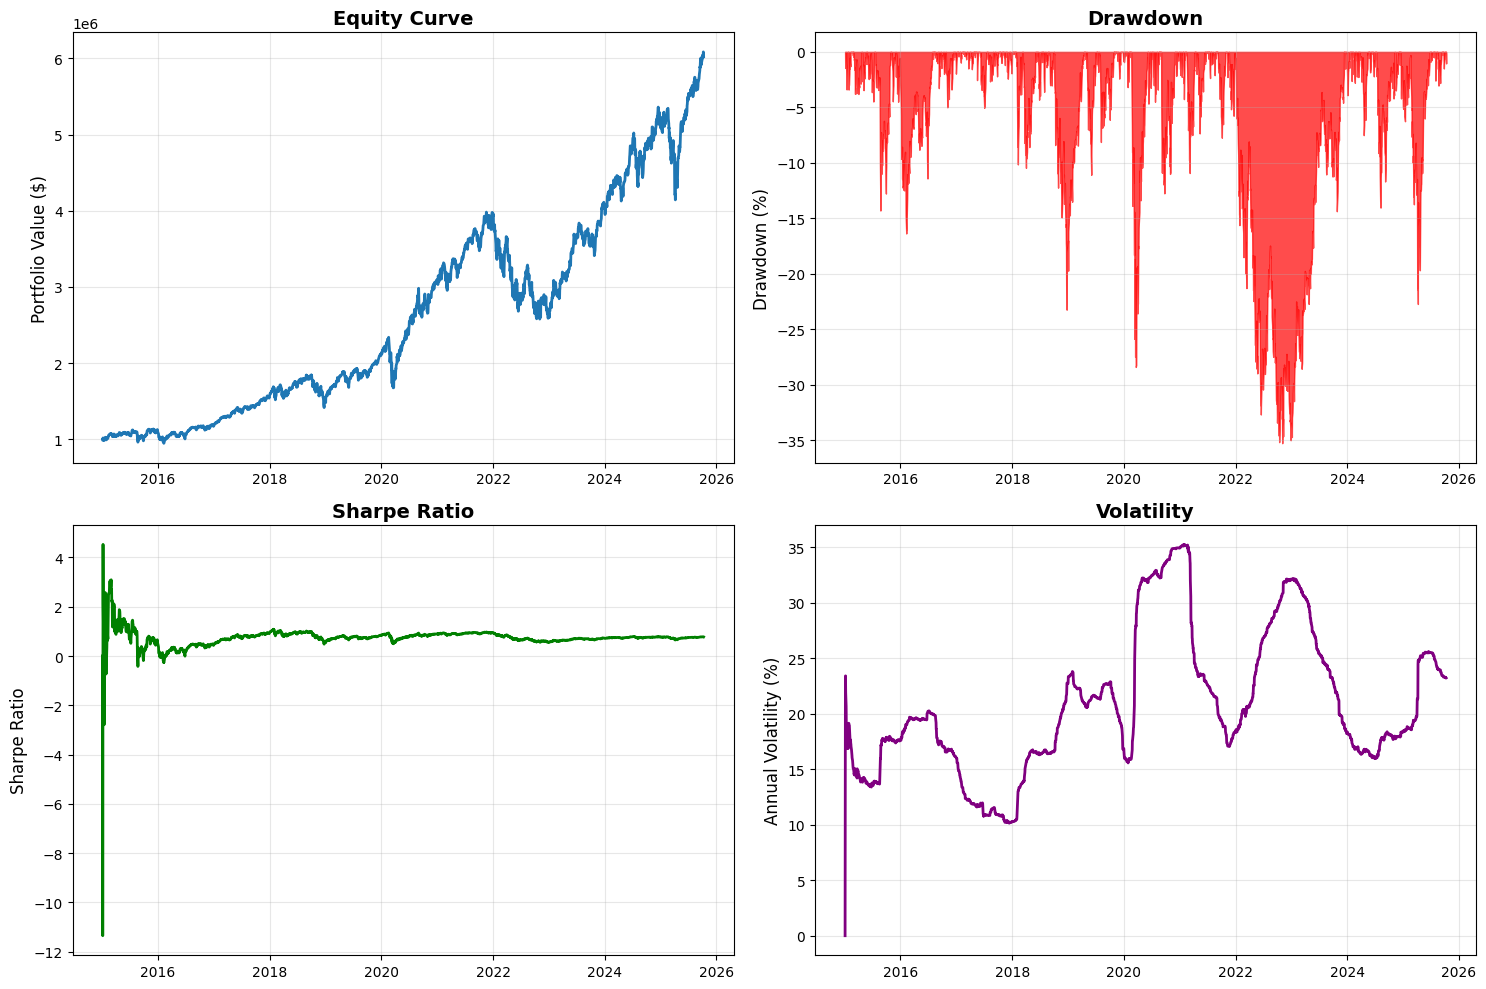

Strategy Performance:
total_return_pct    :   502.3368
cagr_pct            :    18.1569
sharpe_ratio        :     0.7775
max_drawdown_pct    :   -35.2760
calmar_ratio        :     0.5147
volatility_pct      :    23.2331
sortino_ratio       :     1.0032


In [7]:
# Your data
prices_df = pd.DataFrame({"NQ_F": Nq_data.close.values}, index=Nq_data.datetime.values)
weights_df = pd.DataFrame({"NQ_F": 1.0}, index=Nq_data.datetime.values)
prices_df.index = pd.to_datetime(prices_df.index)
weights_df.index = pd.to_datetime(weights_df.index)
# Create metrics
metrics = PortfolioMetrics(prices_df, weights_df)

# Analyze
analyzer = StrategyAnalyzer(metrics)
report = analyzer.generate_report()
analyzer.plot_performance()

print("Strategy Performance:")
for metric, value in report['summary'].items():
    print(f"{metric:20}: {value:10.4f}")

In [8]:
report["summary"]

{'total_return_pct': 502.33675737370487,
 'cagr_pct': 18.1568759879529,
 'sharpe_ratio': 0.7775135345119465,
 'max_drawdown_pct': -35.27601809954747,
 'calmar_ratio': 0.5147087728755254,
 'volatility_pct': 23.233125323826055,
 'sortino_ratio': 1.0032388594629376}

In [9]:
report['rolling_metrics'].round(2)

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,equity,relative_return,volatility,underwater,max_drawdown,sharpe_ratio,mean_return,bias,instruments,avg_turnover,avg_holding_time
2015-01-04,1000000.00,0.00,0.00,0.00,0.00,0.00,0.00,1.0,1,0.0,NaN
2015-01-05,985703.13,-0.01,0.16,-0.01,-0.01,-11.35,-1.80,1.0,1,0.0,NaN
2015-01-06,997537.09,0.01,0.21,-0.00,-0.01,-1.02,-0.19,1.0,1,0.0,NaN
2015-01-07,1016939.99,0.02,0.23,0.00,-0.01,4.53,1.08,1.0,1,0.0,NaN
2015-01-08,1009371.06,-0.01,0.22,-0.01,-0.01,2.14,0.49,1.0,1,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2025-10-05,6051480.75,0.01,0.23,0.00,-0.35,0.78,0.19,1.0,1,0.0,NaN
2025-10-06,6016519.49,-0.01,0.23,-0.01,-0.35,0.78,0.19,1.0,1,0.0,NaN
2025-10-07,6086622.21,0.01,0.23,0.00,-0.35,0.78,0.19,1.0,1,0.0,NaN
2025-10-08,6076590.38,-0.00,0.23,-0.00,-0.35,0.78,0.19,1.0,1,0.0,NaN


In [10]:
report['period_analysis'].round(2)

,year,return_pct,volatility_pct,sharpe_ratio
0,2015,10.24,17.60,0.58
1,2016,6.02,16.09,0.37
2,2017,33.94,10.27,3.30
3,2018,-2.79,22.77,-0.12
4,2019,38.20,16.82,2.27
5,2020,47.22,34.90,1.35
6,2021,26.66,18.38,1.45
7,2022,-32.46,32.21,-1.01
8,2023,54.45,18.25,2.98
9,2024,24.69,18.45,1.34
